In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("G:/Prodigy InfoTech/Task 4/twitter_training.xlsx", header=None)
df.columns = ['Tweet_ID', 'Brand', 'Sentiment', 'Tweet']
df.head()

,Tweet_ID,Brand,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [2]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSentiment Distribution:")
print(df['Sentiment'].value_counts())

Dataset Shape: (74682, 4)

Missing Values:
Tweet_ID       0
Brand          0
Sentiment      0
Tweet        686
dtype: int64

Sentiment Distribution:
Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


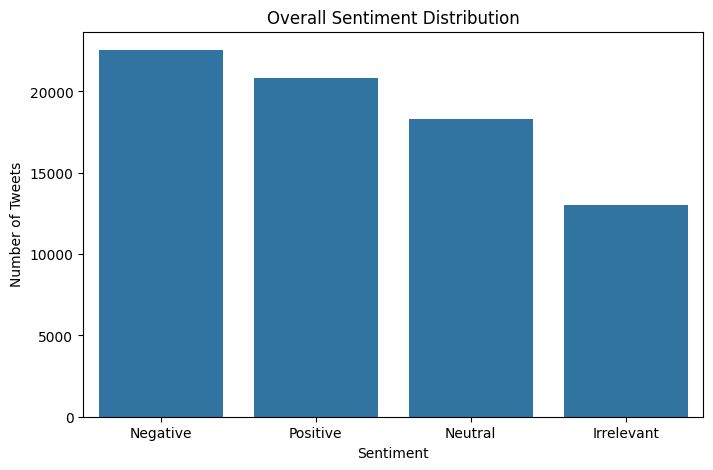

In [3]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Sentiment',
    order=df['Sentiment'].value_counts().index
)

plt.title('Overall Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')

plt.show()

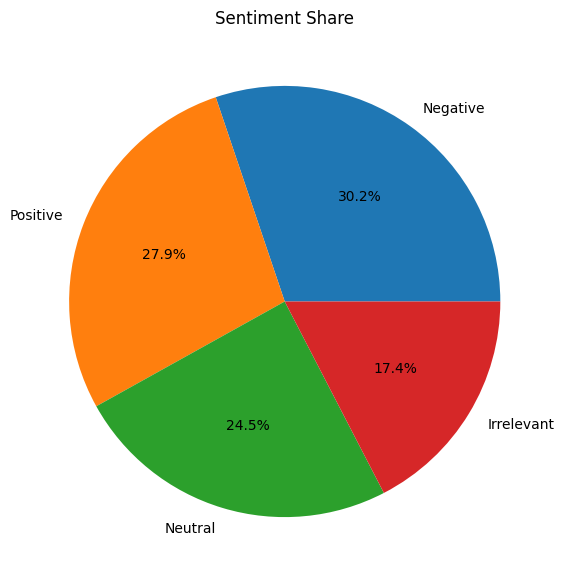

In [4]:
sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Sentiment Share")
plt.show()

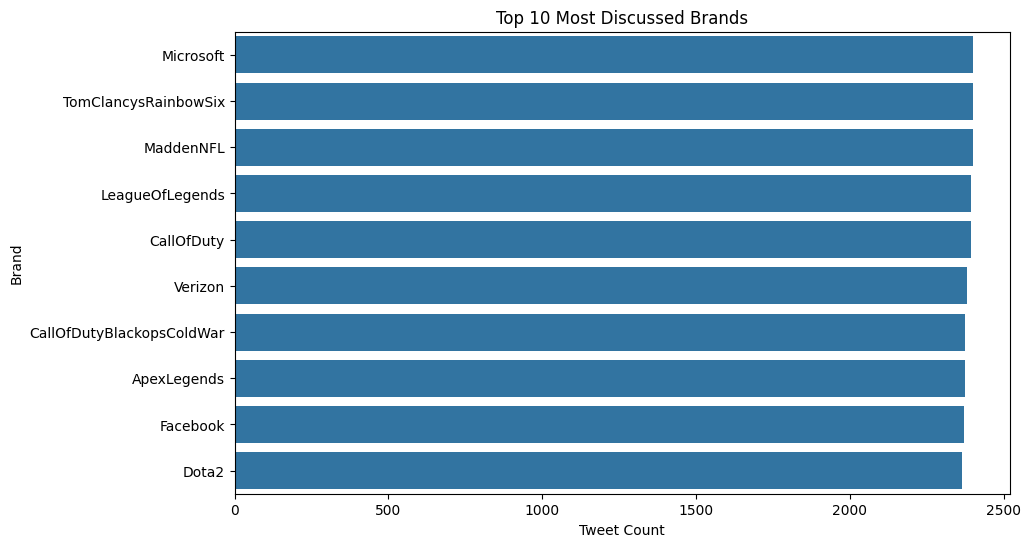

In [5]:
top_brands = df['Brand'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_brands.values,
    y=top_brands.index
)

plt.title("Top 10 Most Discussed Brands")
plt.xlabel("Tweet Count")
plt.ylabel("Brand")

plt.show()

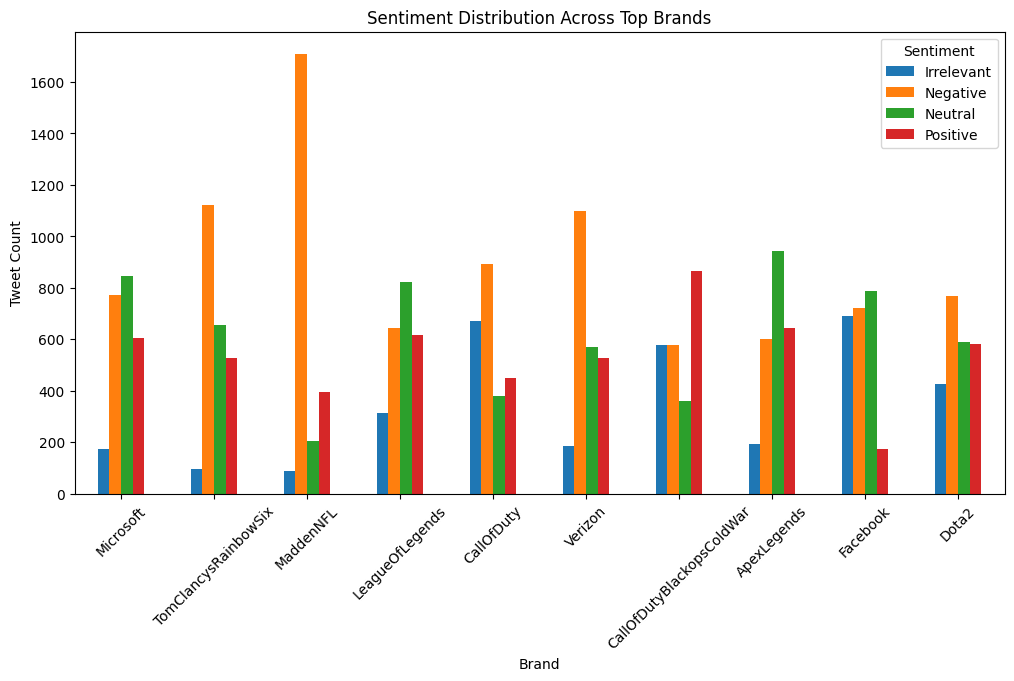

In [6]:
brand_sentiment = pd.crosstab(
    df['Brand'],
    df['Sentiment']
)

top_10_brands = df['Brand'].value_counts().head(10).index

brand_sentiment = brand_sentiment.loc[top_10_brands]

brand_sentiment.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Sentiment Distribution Across Top Brands")
plt.xlabel("Brand")
plt.ylabel("Tweet Count")
plt.xticks(rotation=45)

plt.show()

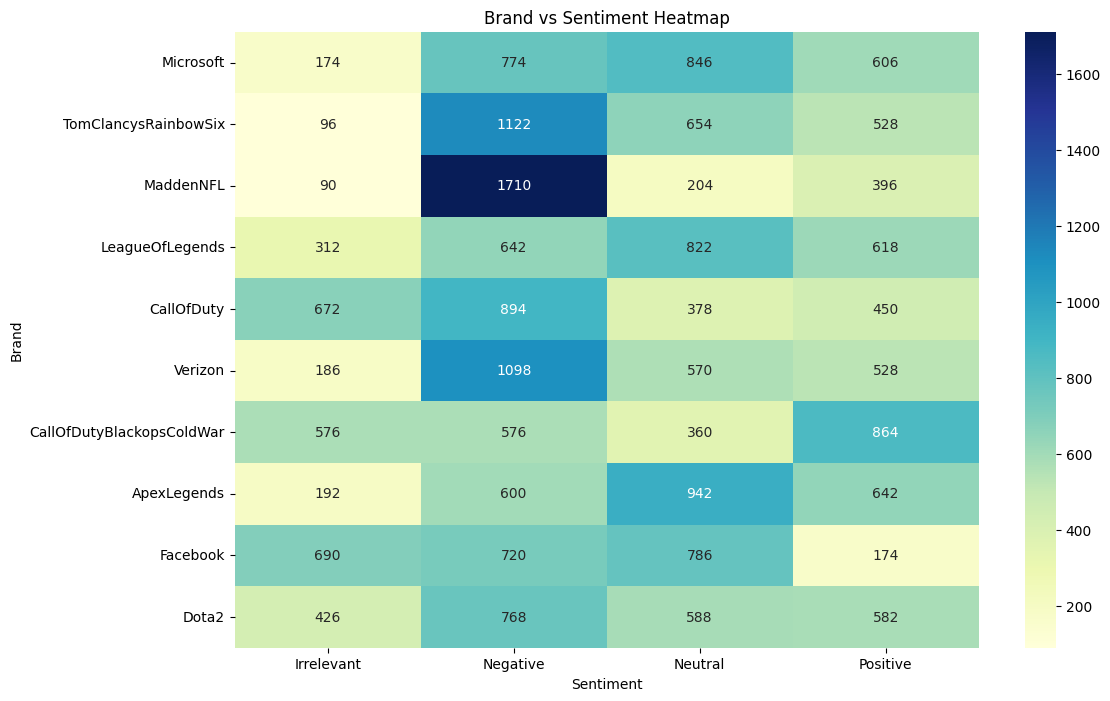

In [7]:
plt.figure(figsize=(12,8))

sns.heatmap(
    brand_sentiment,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Brand vs Sentiment Heatmap")

plt.show()

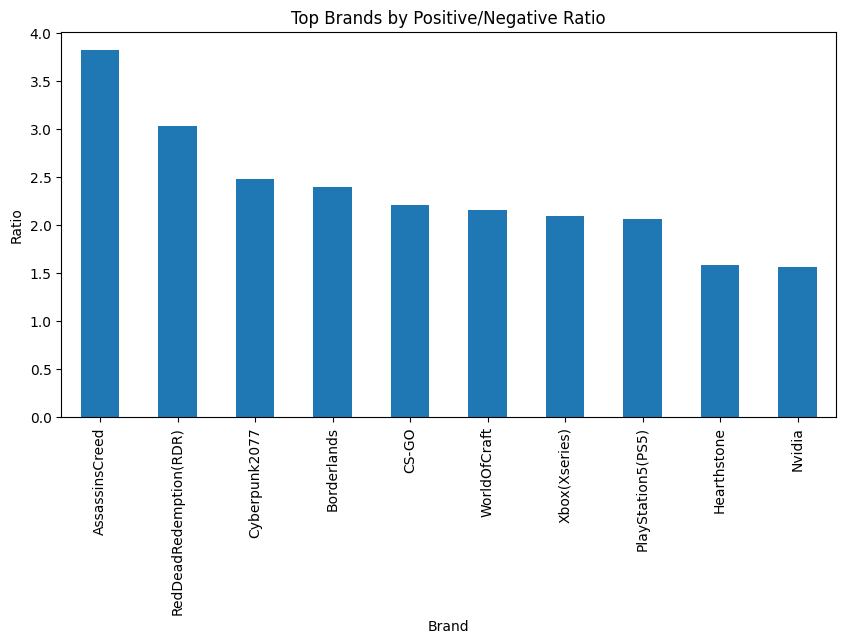

In [8]:
sentiment_table = pd.crosstab(
    df['Brand'],
    df['Sentiment']
)

sentiment_table['Positive_Negative_Ratio'] = (
    sentiment_table['Positive'] /
    sentiment_table['Negative']
)

top_ratio = sentiment_table.sort_values(
    'Positive_Negative_Ratio',
    ascending=False
).head(10)

top_ratio['Positive_Negative_Ratio'].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Brands by Positive/Negative Ratio")
plt.ylabel("Ratio")

plt.show()

In [10]:
print(df['Tweet'].head())
print(df['Tweet'].isnull().sum())

0    im getting on borderlands and i will murder yo...
1    I am coming to the borders and I will kill you...
2    im getting on borderlands and i will kill you ...
3    im coming on borderlands and i will murder you...
4    im getting on borderlands 2 and i will murder ...
Name: Tweet, dtype: object
686


In [11]:
df['Tweet'] = df['Tweet'].fillna('')

df['Tweet_Length'] = df['Tweet'].astype(str).str.len()

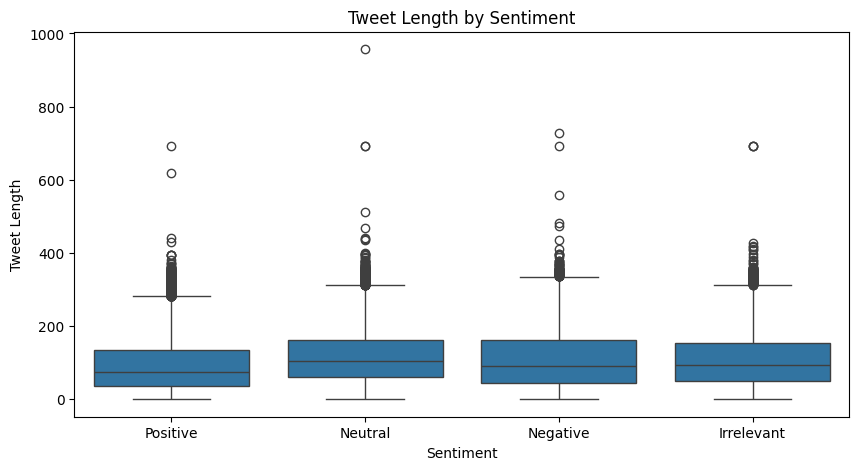

In [12]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='Sentiment',
    y='Tweet_Length'
)

plt.title("Tweet Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Length")

plt.show()